# Computer Vision, Assignment 4: Model Fitting and Local Optimization

In this assignment, you will how to robustly estimate camera parameters and how to jointly optimize the scene geometry. 
You will mainly use RANSAC and Bundle Adjustment.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade.
All computer exercises that are not marked **OPTIONAL** are "mandatory" in the sense described on Canvas.


### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


### Reusing functions from prior assignment:
In this assignment, you will build on your prior work. Many of the exercises require you to use functions implemented in assignment 3. To do so most easily, we recommend that you paste those functions into `helpers.py` and import them here by e.g. `from helpers import estimate_F_DLT`. 

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Note: These functions are provided for your convenience, use them where needed
from supplied import pflat, plot_camera, rital

# Estimate Essential Matrix using RANSAC

#### *Theoretical exercises 1-2* (see pdf)

## Computer Exercise 1
<figure align="center">
    <img alt="left" src="data/round_church1.jpg" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/round_church2.jpg" width="250px">
    <img alt="right" src="data/round_church_recon.png" width="250px">
    <figcaption>Figure 1: Two images of a church and an example of the obtained 3D reconstruction.</figcaption>
</figure>

The goal of this exercise is to robustly estimate essential matrix $E$ from point matches between the two images. For this, we will use RANSAC with an eight point solver.

The data provided contains calibration matrix $K$, which is the same for both images, and a cell $\mathbf{x}$ with matched image points for the two images. Note that $\mathbf{x}$ are noisy and contain some fraction of outliers.

In [2]:
# First we supply some preliminaries, just loading images and data
img1 = plt.imread('./data/round_church1.jpg')
img2 = plt.imread('./data/round_church2.jpg')

data = sp.io.loadmat('./data/compEx1data.mat')
K = data["K"]
x = [x.astype(np.float32) for x in data['x'][0]]

### Task 1.1

First, compute the essential matrix $E$ with an eight point algorithm using all the point correspondences. Remember to normalize image points using $K$ beforehand. Then convert it to a fundamental matrix $F$. Recall that in Assignment 3, you created functions `estimate_F_DLT(x1s, x2s)`, `enforce_essential(E_approx)`, and `convert_E_to_F(E,K1,K2)`.

In [3]:
# Optional imports
from helpers import estimate_F_DLT, enforce_essential, convert_E_to_F, enforce_fundamental

In [4]:
# Extract point correspondences
x1s = x[0]          # 3xN, points in image 1 (homogeneous)
x2s = x[1]          # 3xN, points in image 2 (homogeneous)

# 1) Normalize image points using K
K_inv = np.linalg.inv(K)
x1n = K_inv @ x1s   # normalized camera coords in view 1
x2n = K_inv @ x2s   # normalized camera coords in view 2

# 2) Eight-point algorithm on normalized points → approximate essential
E_approx, s_min, Mv_norm = estimate_F_DLT(x1n, x2n)

# 3) Enforce essential matrix constraints (singular values 1, 1, 0)
E = enforce_essential(E_approx)

# 4) Convert essential matrix back to fundamental matrix
F = convert_E_to_F(E, K, K)

print("Essential matrix E:\n", E)
print("Fundamental matrix F:\n", F)

Minimum singular value of M: 0.9287612354684049
Norm of Mv: 0.9287612354684023
Essential matrix E:
 [[-2.57965096e-02 -9.99612506e-01  9.89107707e-03]
 [ 9.98372444e-01 -2.52566374e-02  5.11296102e-02]
 [ 4.84385425e-04 -3.41098887e-03  6.29039845e-05]]
Fundamental matrix F:
 [[-4.50121763e-09 -1.74118760e-07  1.17721271e-04]
 [ 1.73902758e-07 -4.39171588e-09 -1.38063952e-04]
 [-1.04857823e-04  1.63682029e-04 -2.22525984e-02]]


### Task 1.2 

Compute the epipolar lines $\mathbf{l}_2 = F\mathbf{x}_1$ and $\mathbf{l}_1 = F^T\mathbf{x}_2$. Compute the RMS distance between the image points ($\mathbf{x}_1$ and $\mathbf{x}_2$) and corresponding epipolar lines ($\mathbf{l}_1$ and $\mathbf{l}_2$, respectively). 

\begin{align}
& e_{RMS} = \sqrt{\frac{1}{2m}
\left(
\sum_{i=1}^{m} d^2({\mathbf{x}_1}_i,{\mathbf{l}_1}_i) + 
\sum_{i=1}^{m} d^2({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)
\right)
},\nonumber \\
& \text{where }~d(\mathbf{x}, \mathbf{l}) = \frac{|l_{1}x_{1}+l_{2}x_{2}+l_{3}|}{\sqrt{l_{1}^2+l_{2}^2}}.
\end{align}

In Assignment 3, you implemented the distances $d(\mathbf{x}, \mathbf{l})$ from image points to the corresponding epipolar lines for the second image in the function `compute_epipolar_errors(F, x1s, x2s)`.


**HINT:** If you transpose the fundamental matrix and change the order of the correpondences, i.e. run `compute_epipolar_errors(F.T, x2s, x1s)` you can obtain the errors to the epipolar lines in the first image.

In [5]:
# Optional imports
from helpers import compute_epipolar_errors 

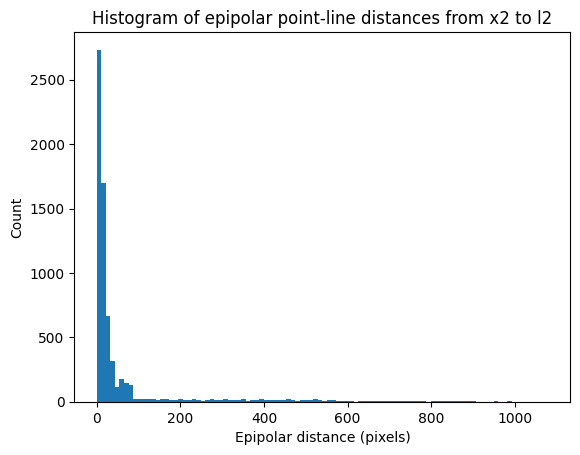

Mean epipolar distance: 63.46892701068398


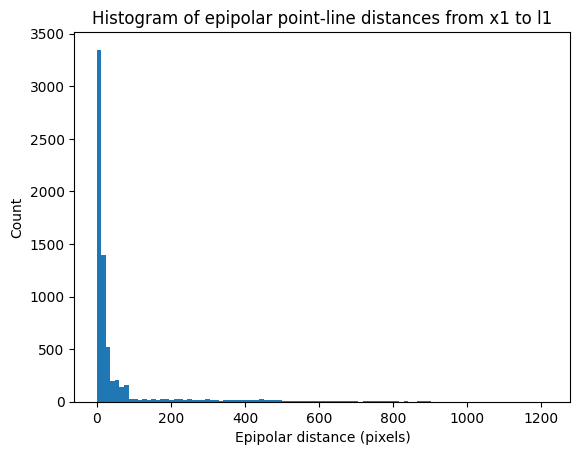

Mean epipolar distance: 61.3336058307846
RMS epipolar distance e_RMS = 155.95832213704287


In [6]:
# Epipolar lines (optional, if you want them explicitly)
l2 = F @ x1s      # 3 x m, lines in image 2 corresponding to x1
l1 = F.T @ x2s    # 3 x m, lines in image 1 corresponding to x2

# Distances from x2 to l2 (lines in image 2)
d2, mean2 = compute_epipolar_errors(F, x1s, x2s)
plt.figure()
plt.hist(d2, bins=100)
plt.xlabel('Epipolar distance (pixels)')
plt.ylabel('Count')
plt.title('Histogram of epipolar point-line distances from x2 to l2')
plt.show()
print("Mean epipolar distance:", mean2)

# Distances from x1 to l1 (lines in image 1)
d1, mean1 = compute_epipolar_errors(F.T, x2s, x1s)
plt.figure()
plt.hist(d1, bins=100)
plt.xlabel('Epipolar distance (pixels)')
plt.ylabel('Count')
plt.title('Histogram of epipolar point-line distances from x1 to l1')
plt.show()
print("Mean epipolar distance:", mean1)

# Number of correspondences
m = x1s.shape[1]

# RMS error across both images:
e_RMS = np.sqrt((np.sum(d1**2) + np.sum(d2**2)) / (2.0 * m))

print("RMS epipolar distance e_RMS =", e_RMS)

### Task 1.3

Plot two separate histograms with 100 bins for the epipolar errors $\{d({\mathbf{x}_1}_i,{\mathbf{l}_1}_i)\}$ in the first image and $\{d({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)\}$ in the second image, respectively. See for example your solution to Assignment 3 Computer Exercise 2.2 for some code on plotting histograms.

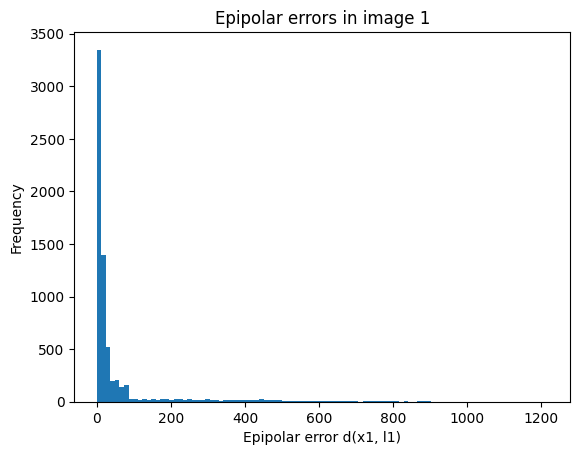

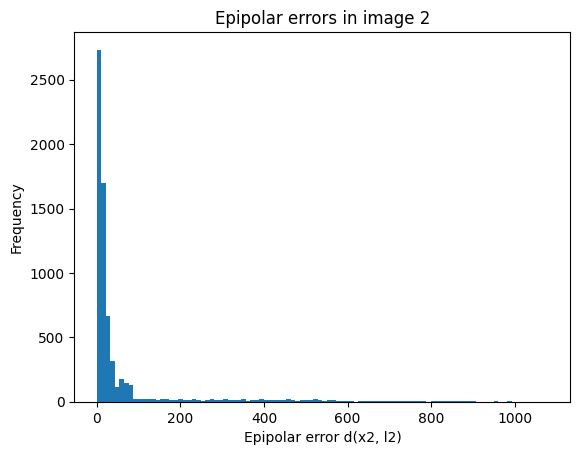

In [7]:
plt.figure()
plt.hist(d1, bins=100)
plt.xlabel('Epipolar error d(x1, l1)')
plt.ylabel('Frequency')
plt.title('Epipolar errors in image 1')

plt.figure()
plt.hist(d2, bins=100)
plt.xlabel('Epipolar error d(x2, l2)')
plt.ylabel('Frequency')
plt.title('Epipolar errors in image 2')

plt.show()

### Task 1.4

Pick 20 points in the first image at random and plot these in the same figure as the image. Also plot the corresponding epipolar lines in the same image using the function `rital`. Repeat the plot for the second image.

Q: **Do the plots look reasonable, are points close to the epipolar lines? If not, what do you think could be the cause of the bad estimate?** 

A: No, the points are not on the epipolar lines. Epipolar errors may be the reason that cause points not close to lines.

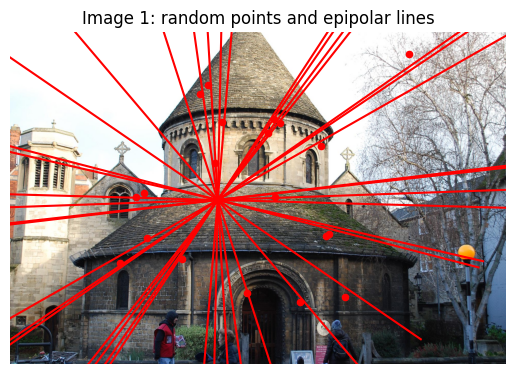

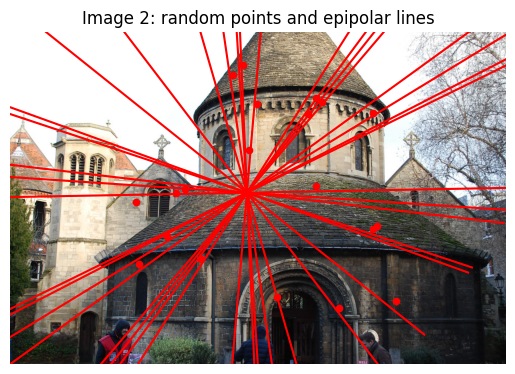

In [8]:
m = x1s.shape[1]
idx = np.random.choice(m, size=20, replace=False)

# Sample corresponding points
x1_sample = x1s[:, idx]   # 3x20
x2_sample = x2s[:, idx]   # 3x20

# Lines (still 3x20)
l1_sample = F.T @ x2_sample   # lines for image 1
l2_sample = F @ x1_sample     # lines for image 2

# -------- Image 1 --------
plt.figure()
plt.imshow(img1)
plt.axis('off')

x1s_norm = pflat(x1_sample)

plt.scatter(x1s_norm[0, :],
            x1s_norm[1, :],
            c='r', s=20)

# rital expects lines as N x 3 → transpose
rital(l1_sample.T)
plt.title('Image 1: random points and epipolar lines')

# -------- Image 2 --------
plt.figure()
plt.imshow(img2)
plt.axis('off')

x2s_norm = pflat(x2_sample)

plt.scatter(x2s_norm[0, :],
            x2s_norm[1, :],
            c='r', s=20)

rital(l2_sample.T)
plt.title('Image 2: random points and epipolar lines')

plt.show()

### Task 1.5

Next, use RANSAC to robustly compute $E$. Create a function `estimate_E_robust(x1, x2, eps)` that does it, where `eps` is the inlier threshold. Remember again to normalize `x1` and `x2` using $K$ beforehand. Note that for this problem of estimating $E$, a point correspondence $({\mathbf{x}_1}_i, {\mathbf{x}_2}_i)$ is a single measurement. Use the same eight point solver as above.

Note that this time only a subset of correspondences will be used by this solver (since in the RANSAC loop, you first randomly sample a subset of correspondences and then compute candidate $E$ from this subset).

Finally, to make RANSAC work, you need to implement an error function that measures how far a single measurement ($({\mathbf{x}_1}_i, {\mathbf{x}_2}_i)$) is to the candidate model ($E$). Use the following error function: $\frac12 \left ( d^2({\mathbf{x}_1}_i,{\mathbf{l}_1}_i) + d^2({\mathbf{x}_2}_i,{\mathbf{l}_2}_i)\right )$, where the epipolar lines ${\mathbf{l}_j}_i$ are computed as before but using $E$ (and therefore are normalized). This error should be familiar to you based on the previous exercises, reuse your implementation from there!

A suggested inlier threshold is 2px (which should also be normalized, see function description below). 

Q: **How many inliers did you get for the returned solution of $E$?**

A: 580

In [11]:
def estimate_E_robust(x1, x2, eps, seed=None):
    """
    RANSAC estimate of essential matrix using normalized correspondences x1 and x2 and a normalized threshold.
    Note: Make sure to normalize things before using it in this function!
    -------------------------------------------
    x1: Normalized keypoints in image 1 - 3xN np.array or 2xN np.array, as you desire 
    x2: Normalized keypoints in image 2 - 3xN np.array or 2xN np.array, as you desire 
    eps: Normalized inlier threshold - float

    Returns:
    E: 3x3 essential matrix
    inliers: The inlier points
    errs: The epipolar errors
    iters: How many iterations it took
    """
    # TIPS: 
    # * You can use the already created functions, enforce_essential, estimate_F_DLT, and compute_epipolar_errors
    # * Normalizing the pixel threshold can be done by e.g. eps = threshold_px / K[0,0]
    # * To create an estimate for E using DLT for a random subset of calibrated correspondences...
    # ...you can chain your functions like: E = enforce_essential(estimate_F_DLT(x1[:, randind], x2[:, randind]))

    # * Pseudo code for computing inliers:
    # e1 = compute_epipolar_errors(E, x1, x2)**2 
    # e2 = compute_epipolar_errors(E.T, x2, x1)**2
    # inliers = (1/2)*(e1+e2) < eps**2

    if seed is not None:
        np.random.seed(seed)

    # Ensure homogeneous 3xN
    if x1.shape[0] == 2:
        x1h = np.vstack((x1, np.ones((1, x1.shape[1]))))
    else:
        x1h = x1.copy()
    if x2.shape[0] == 2:
        x2h = np.vstack((x2, np.ones((1, x2.shape[1]))))
    else:
        x2h = x2.copy()

    N = x1h.shape[1]
    assert N == x2h.shape[1]

    sample_size = 8            # eight-point algorithm
    max_iters = 1000
    best_inliers = None
    best_E = None
    best_num_inliers = 0

    # Preallocate for final errors
    best_errs = None

    for it in range(max_iters):
        print(f"Iteration {it + 1}")
        # 1. Random minimal sample
        idx = np.random.choice(N, size=sample_size, replace=False)

        # 2. Estimate candidate E from this subset
        E_approx, _, _ = estimate_F_DLT(x1h[:, idx], x2h[:, idx])
        E = enforce_essential(E_approx)  

        # 3. Compute symmetric epipolar error for all points
        # compute_epipolar_errors returns per-point distances
        e2, _ = compute_epipolar_errors(E, x1h, x2h)       # d(x2, l2), l2 = E x1
        e1, _ = compute_epipolar_errors(E.T, x2h, x1h)     # d(x1, l1), l1 = E^T x2

        e_sym_sq = 0.5 * (e1**2 + e2**2)   # shape (N,)

        # 4. Inlier test
        inliers = e_sym_sq < (eps**2)
        num_inliers = np.sum(inliers)

        # 5. Keep best model so far
        if num_inliers > best_num_inliers:
            best_num_inliers = num_inliers
            best_inliers = inliers
            best_E = E
            best_errs = e_sym_sq
        print("=====================================================")

    # Optional: re-estimate E using all inliers (refinement)
    if best_inliers is not None and best_num_inliers >= sample_size:
        inlier_idx = np.where(best_inliers)[0]
        E_approx, _, _ = estimate_F_DLT(x1h[:, inlier_idx], x2h[:, inlier_idx])
        best_E = enforce_essential(E_approx)

        # Recompute final symmetric errors for reporting
        e2, _ = compute_epipolar_errors(best_E, x1h, x2h)
        e1, _ = compute_epipolar_errors(best_E.T, x2h, x1h)
        best_errs = 0.5 * (e1**2 + e2**2)

    # iters: number of iterations actually performed
    iters = max_iters

    # Return:
    # E: 3x3
    # inliers: boolean mask length N
    # errs: per-point symmetric epipolar error (N,)
    # iters: iterations used
    return best_E, best_inliers, best_errs, iters

### Task 1.6

Again, compute the RMS distance between the image points and corresponding estimated epipolar lines in both images. Also plot a histogram of epipolar errors for both images as before. 

Q: **Which is the better estimate of the essential matrix, and why?** Repeat plotting 20 random points with the corresponding epipolar lines, but this time pick random points from the subset of correspondences that are ***inliers***.

A: The RANSAC-based essential matrix is the better estimate, because it is fitted only to geometrically consistent inlier correspondences and therefore yields lower symmetric epipolar error and epipolar lines that pass close to the observed points.

Iteration 1
Minimum singular value of M: 4.1088006841974534e-05
Norm of Mv: 9.904648229100558e-17
Iteration 2
Minimum singular value of M: 0.0009912599589027406
Norm of Mv: 2.4520425251479434e-16
Iteration 3
Minimum singular value of M: 0.002812058355040511
Norm of Mv: 8.457242583500752e-17
Iteration 4
Minimum singular value of M: 0.001131390135727766
Norm of Mv: 8.911033845127446e-17
Iteration 5
Minimum singular value of M: 4.819950872743111e-05
Norm of Mv: 5.480188871771525e-17
Iteration 6
Minimum singular value of M: 0.00288001428763263
Norm of Mv: 3.043750798793865e-16
Iteration 7
Minimum singular value of M: 0.00010583294486007833
Norm of Mv: 9.51413198280327e-17
Iteration 8
Minimum singular value of M: 0.00012085679786125437
Norm of Mv: 1.7358506800138636e-16
Iteration 9
Minimum singular value of M: 5.9508676120997114e-05
Norm of Mv: 4.4565853017184997e-17
Iteration 10
Minimum singular value of M: 0.0044081964893664905
Norm of Mv: 3.03948107445704e-17
Iteration 11
Minimum singula

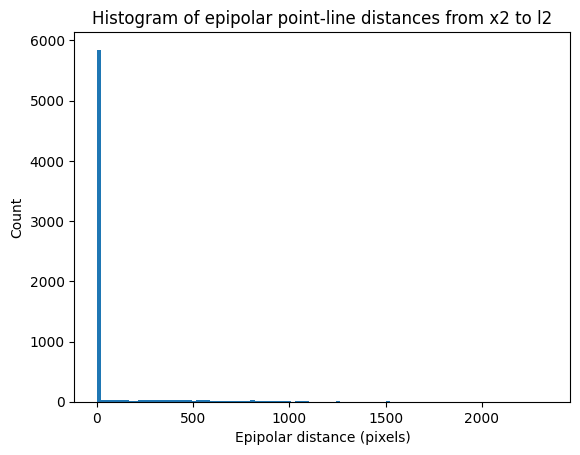

Mean epipolar distance: 70.9423049564075


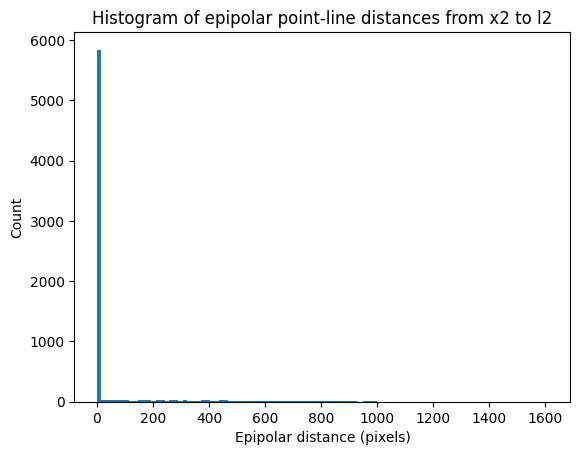

Mean epipolar distance: 58.10405322137908


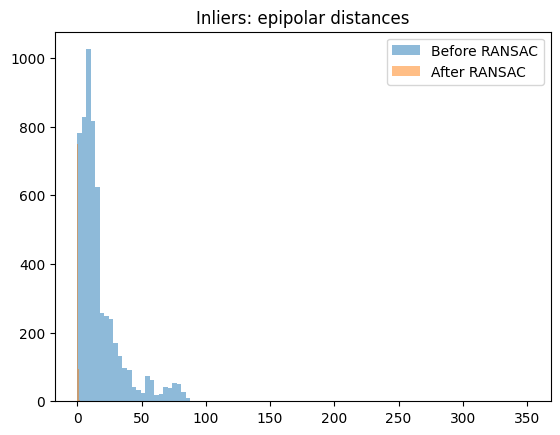

Robust RMS epipolar distance e_RMS = 209.72883925642893


In [12]:
# From earlier steps
x1s = x[0]          # 3xN pixel coords, homogeneous
x2s = x[1]          # 3xN pixel coords, homogeneous

threshold_px = 2.0
eps = threshold_px / K[0, 0]
E_robust, inliers, errs, iters = estimate_E_robust(x1n, x2n, eps)
num_inliers = np.sum(inliers)
print("Number of inliers:", num_inliers)

# Convert robust essential matrix to fundamental matrix in pixel coordinates
F_robust = convert_E_to_F(E_robust, K, K)

# Epipolar distances in both images
d2_robust, mean2_robust = compute_epipolar_errors(F_robust,  x1s, x2s)   # d(x2, l2)
plt.figure()
plt.hist(d2_robust, bins=100)
plt.xlabel('Epipolar distance (pixels)')
plt.ylabel('Count')
plt.title('Histogram of epipolar point-line distances from x2 to l2')
plt.show()
print("Mean epipolar distance:", mean2_robust)

d1_robust, mean1_robust = compute_epipolar_errors(F_robust.T, x2s, x1s)  # d(x1, l1)
plt.figure()
plt.hist(d1_robust, bins=100)
plt.xlabel('Epipolar distance (pixels)')
plt.ylabel('Count')
plt.title('Histogram of epipolar point-line distances from x2 to l2')
plt.show()
print("Mean epipolar distance:", mean1_robust)

m = x1s.shape[1]

# RMS error over all points and both images
e_RMS_robust = np.sqrt((np.sum(d1_robust**2) + np.sum(d2_robust**2)) / (2.0 * m))

# BEFORE: from non‑robust F (call it F_raw)
d2_raw, _ = compute_epipolar_errors(F,  x1s, x2s)
d1_raw, _ = compute_epipolar_errors(F.T, x2s, x1s)

# AFTER RANSAC: you already have d1_robust, d2_robust
# Use the inlier mask from RANSAC to compare only inliers
inlier_idx = np.where(inliers)[0]

d2_raw_in  = d2_raw[inlier_idx]
d1_raw_in  = d1_raw[inlier_idx]
d2_rob_in  = d2_robust[inlier_idx]
d1_rob_in  = d1_robust[inlier_idx]

plt.figure()
plt.hist(d2_raw_in, bins=100, alpha=0.5, label='Before RANSAC')
plt.hist(d2_rob_in, bins=100, alpha=0.5, label='After RANSAC')
plt.legend()
plt.title('Inliers: epipolar distances')
plt.show()

print("Robust RMS epipolar distance e_RMS =", e_RMS_robust)

## Computer Exercise 2
<figure align="center">
    <img alt="left" src="data/fountain1.png" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/fountain2.png" width="250px">
    <img alt="right" src="data/fountain_recon.png" width="250px">
    <figcaption>Figure 2: Two images of a fountain and an example of the obtained 3D reconstruction.</figcaption>
</figure>

In this exercise you will build a 2-view reconstruction pipeline that connects feature extraction,
matching, robust essential matrix estimation from the previous computer exercise, and triangulation.

You can use the two supplied images from the data and the intrinsics provided. We load the required data for your convenience below:

In [16]:
data = sp.io.loadmat('./data/compEx2data.mat')
K = data['K']
img1 = (plt.imread('./data/fountain1.png') * 255).astype('uint8')
img2 = (plt.imread('./data/fountain2.png') * 255).astype('uint8')

### Task 2.1

We will begin by computing SIFT features and matching them. Since OpenCV has quite a difficult API for this we have supplied some code snippets. And you already learned much of the basics of this from Assignment 2, so we provide some basic code to get you started.

The implementation is based on their official guide for image matching (https://docs.opencv.org/3.4/dc/dc3/tutorial_py_matcher.html) and uses Lowe's ratio test to filter out matches that are too similar, this should be similar to what you have done in previous assignments.

In [17]:
# Some supplied code on how to compute matches using OpenCV

from cv2 import SIFT_create, cvtColor, COLOR_RGB2GRAY, FlannBasedMatcher, drawMatchesKnn
rgb2gray = lambda img: cvtColor(img, COLOR_RGB2GRAY)
sift = SIFT_create(contrastThreshold=0.02, edgeThreshold=10, nOctaveLayers=3)

# We detect keypoints and simultaneously describe them using SIFT
kp1, des1 = sift.detectAndCompute(rgb2gray(img1),None)
kp2, des2 = sift.detectAndCompute(rgb2gray(img2),None)

# We use a k-NN-like system to find the most similar descriptions
all_matches = FlannBasedMatcher().knnMatch(des1, des2, k=2)
# Apply ratio test
# Here we filter out matches that are too similar to other matches (because then they are likely wrong)
# This is standard in OpenCV, see https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
matches = []
for m,n in all_matches:
    if m.distance < 0.75*n.distance:
        matches.append([m])

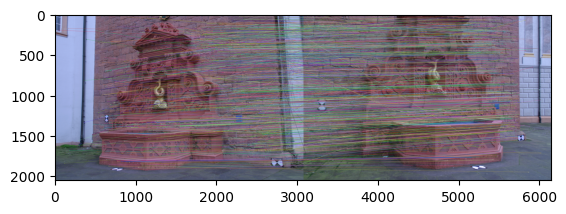

(<matplotlib.image.AxesImage at 0x13f2507c0>, None)

In [18]:
# Run this code for a simple plot of the filtered matches

# Just making sure no other figures are impacting this one
plt.close()
plt.clf()   
plt.cla() 
# Here is some supplied code from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
# Feel free to play around with it
img3 = drawMatchesKnn(img1,kp1,img2,kp2,matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3,),plt.show()

Q: **Run the code above. Do the matches look reasonable?**

A: Yes, it's reasonable.

Q: **How many SIFT features did you find for the two images, respectively? How many total matches did you find? How many good matches did you find after the ratio test?**

A: </br>
Number of SIFT features in image 1: 19408 </br>
Number of SIFT features in image 2: 17616 </br>
Number of total matches (k-NN pairs): 19408 </br>
Number of good matches after ratio test: 1034 </br>

In [19]:
# Count SIFT features per image
num_kp1 = len(kp1)
num_kp2 = len(kp2)
print("Number of SIFT features in image 1:", num_kp1)
print("Number of SIFT features in image 2:", num_kp2)

# Count number of total matches (before ratio test)
# all_matches is a list of k-NN matches; here k = 2
num_total_matches = len(all_matches)
print("Number of total matches (k-NN pairs):", num_total_matches)

# Count the number of good matches after the ratio-test
num_good_matches = len(matches)
print("Number of good matches after ratio test:", num_good_matches)


Number of SIFT features in image 1: 19408
Number of SIFT features in image 2: 17616
Number of total matches (k-NN pairs): 19408
Number of good matches after ratio test: 1034


Now we supply a little more code just to make it easier. We extract the keypoints corresponding to the good matches and save them as x1 and x2. We do this because currently the type of kp1 etc... are OpenCV specific

In [20]:
# Supplied code for extracting numpy arrays from matching keypoints
# Note, x1 and x2 are in homogenous coordinates after this
x1 = np.array([[kp1[match[0].queryIdx].pt[0], kp1[match[0].queryIdx].pt[1]] for match in matches])
x2 = np.array([[kp2[match[0].trainIdx].pt[0], kp2[match[0].trainIdx].pt[1]] for match in matches])
x1 = np.vstack((x1.T, np.ones(x1.shape[0])))
x2 = np.vstack((x2.T, np.ones(x2.shape[0])))
x = np.array([x1, x2])

### Task 2.2

Now you should find the essential matrix describing the transformation between the two images.
Because not all matches are correct, you need to use RANSAC to find a set of good correspondences (inliers). 
To estimate the essential matrix use the function `estimate_E_robust(x1,x2,eps)` that you created in the previous computer exercise.

Q: **How many inliers did you find?**

A: 632

In [21]:
# x1, x2, K are already defined as in the supplied code:
# x1, x2 : 3xN homogeneous pixel coordinates from SIFT matches

# 1) Normalize points with K
K_inv = np.linalg.inv(K)
x1_norm = K_inv @ x1   # 3xN, normalized camera coords
x2_norm = K_inv @ x2   # 3xN

# 2) Choose normalized inlier threshold (e.g. 2 pixels)
threshold_px = 2.0
eps = threshold_px / K[0, 0]   # normalized threshold

# 3) Compute robust essential matrix using your previous function
E_robust, inliers, errs, iters = estimate_E_robust(x1_norm, x2_norm, eps)

# 4) Print the number of inliers
num_inliers = np.sum(inliers)
print("Number of inliers:", num_inliers)
print("Total number of matches:", inliers.shape[0])
print("Inlier ratio:", num_inliers / inliers.shape[0])


Iteration 1
Minimum singular value of M: 0.006701436871771794
Norm of Mv: 1.4768600685300367e-16
Iteration 2
Minimum singular value of M: 0.004045854228608472
Norm of Mv: 7.05928022612927e-17
Iteration 3
Minimum singular value of M: 0.061727624957936426
Norm of Mv: 2.8160285058952163e-16
Iteration 4
Minimum singular value of M: 0.014360753547119576
Norm of Mv: 2.384598113058742e-16
Iteration 5
Minimum singular value of M: 0.012600864325850447
Norm of Mv: 1.790718670647276e-16
Iteration 6
Minimum singular value of M: 0.014000960741684713
Norm of Mv: 2.9275225451776116e-16
Iteration 7
Minimum singular value of M: 0.02014641063559991
Norm of Mv: 8.925400940993413e-17
Iteration 8
Minimum singular value of M: 0.002515834064878052
Norm of Mv: 1.337988067442568e-16
Iteration 9
Minimum singular value of M: 0.002764034016160516
Norm of Mv: 9.412373634839028e-17
Iteration 10
Minimum singular value of M: 0.000961218747538007
Norm of Mv: 3.046452994232769e-16
Iteration 11
Minimum singular value of

### Task 2.3

After getting the robust essential matrix estimation, you should find the camera matrix of the second view. Remember that there are 4 possible solutions (see Theoretical Exercise 7 of HA3)! You should pick the solution that has more points in front of the camera. Remember, in Assigment 3 you implemented `extract_P_from_E(E)`

**Hint:** You need to perform triangulation by using a function from a previous computer exercise. The 3D points X and the 2d correspondences x1 and x2 wil also be needed for the next task in this assignment!

Q: **Which of the solutions seems correct to you?**

A: The correct solution is the best_idx candidate. Its camera center and orientation lead to the largest number of triangulated points with positive depth in both views, which matches the physical requirement that scene points must lie in front of both cameras.

In [22]:
# Optional import
from helpers import extract_P_from_E, triangulate_points_DLT

Candidate 0: points in front of both cameras = 0
Candidate 1: points in front of both cameras = 0
Candidate 2: points in front of both cameras = 632
Candidate 3: points in front of both cameras = 0
Best camera index: 2 with 632 points in front of both cameras


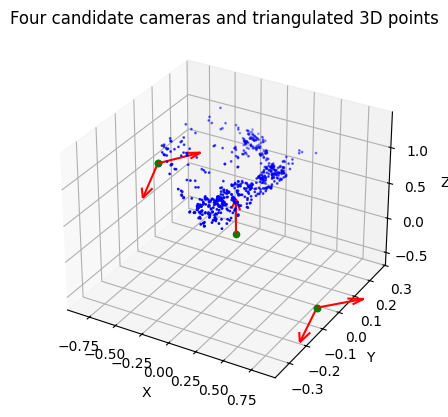

In [23]:
# Canonical first camera in *normalized* coordinates
P1_norm = np.hstack((np.eye(3), np.zeros((3, 1))))  # [I | 0]

# 4 possible second cameras in normalized coordinates (from E)
P2_norm_candidates = extract_P_from_E(E_robust)   # list of 4 (3x4) matrices

# Use only inlier correspondences
inlier_idx = np.where(inliers)[0]
x1_in = x1[:, inlier_idx]   # 3xM, pixel coords
x2_in = x2[:, inlier_idx]   # 3xM

# Normalize inliers for triangulation with normalized cameras
K_inv = np.linalg.inv(K)
x1_in_norm = K_inv @ x1_in   # 3xM
x2_in_norm = K_inv @ x2_in   # 3xM

best_idx = None
best_num_front = -1
best_X = None

for i, P2_norm in enumerate(P2_norm_candidates):
    # Triangulate using normalized cameras
    X_h = triangulate_points_DLT(P1_norm, P2_norm, x1_in_norm, x2_in_norm)  # 4xM
    X_h = pflat(X_h)  # ensure homogeneous normalization (last row = 1)

    # Depth in camera 1 (canonical [I|0]) is just Z of X_h
    Z1 = X_h[2, :]

    # Depth in camera 2: project with P2_norm
    X_cam2 = P2_norm @ X_h
    Z2 = X_cam2[2, :]

    in_front = (Z1 > 0) & (Z2 > 0)
    num_front = np.sum(in_front)

    print(f"Candidate {i}: points in front of both cameras = {num_front}")

    if num_front > best_num_front:
        best_num_front = num_front
        best_idx = i
        best_X = X_h[:, in_front]  # keep only points in front for best model

print("Best camera index:", best_idx, "with", best_num_front, "points in front of both cameras")

# Build pixel-space camera matrices for plotting
P1 = K @ P1_norm
P2_all = [K @ P2n for P2n in P2_norm_candidates]

# ---- Plot all 4 cameras and triangulated 3D points (best solution) ----
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot first camera
plot_camera(P1, scale=0.5, ax=ax)

# Plot all 4 candidate second cameras
for i, P2 in enumerate(P2_all):
    plot_camera(P2, scale=0.5, ax=ax)

# Plot triangulated 3D points (best solution)
X_best = best_X
X_best_inh = X_best  # already flattened by pflat above
ax.scatter(X_best_inh[0, :], X_best_inh[1, :], X_best_inh[2, :],
           s=1, c='b')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Four candidate cameras and triangulated 3D points')
plt.show()

### Summary of reconstruction pipeline

In summary, you have performed a 2d-view reconstruction pipeline consisting of the following steps:
1. **Load the two images**, find SIFT features, and match them.

2. **Estimate the essential matrix** robustly using  
   `estimate_E_robust(x1, x2, eps)`.

3. **Compute the four possible camera matrix pairs** for the essential matrix, and for each pair:
   1. Triangulate the 3D points using the camera matrix pair and the matched image points.
   2. Compute the camera centers and principal directions of both cameras.
   3. Plot everything in 3D.

4. **Choose the correct solution** (out of the four) by selecting the one that yields the highest number of 3D points (inliers) lying in front of the cameras.  

The final visualization should resemble the right-most result in the first Figure of Computer Exercise 2 after removing most outliers.

This pipeline will come in handy for the project and somewhat resembles the first stage in any modern SfM pipeline like [COLMAP](https://github.com/colmap/colmap).

#### *Theoretical exercises 3* (see pdf)

## Computer Exercise 3

In this exercise you will use the solution from Computer Exercise 2 as a starting point and locally improve it using the Levenberg-Marquardt method. If you have doubts about the correctness of your solution from the earlier exercise, you can instead use the provided data in `compEx3data.mat` as starting solution (you can load it like `data = sp.io.loadmat('./data/compEx3data.mat')` and then use that for your x and camera matrices).

The goal is to refine the solution **3D points (not camera matrices, those you can assume fixed**).
You will loop over the 3D points and update them one by one using Levenberg-Marquardt (LM), please see the lecture notes or [Wikipedia page on Levenberg–Marquardt](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm) for more information.

In short, LM is an iterative method for minimizing a non-linear least squares objective
\begin{equation}
   F(v)=\|r(v)\|^2, 
\end{equation}
with respect to $v$.
In LM, the update is given by
\begin{equation}
\delta v =  - (J(v)^TJ(v)+\mu I)^{-1}J(v)^Tr(v),
\end{equation}
where $J(v)$ is the Jacobian of $r(v)$ at $v$.
Here $\mu>0$ is a damping factor that is adjusted adaptively and $v$ is the previous solution.
The new solution is $v+\delta v$ and we iterate until convergence (or for a fixed number of iterations).

We can also define the **reprojection error** to be: $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ (as in Equation (2) in the Theoretical Exercises)

In our setting, we have $v=X_j$ and $r(v)=r(X_j)$. Please see the main PDF for some more details about the definition of $r$ (e.g. Equation (3) for the definition).

You will have to implement three functions in this exercise:

1. `(err,res) = compute_reprojection_error(P_1,P_2,X_j,x_1j,x_2j)`: a function that computes the reprojection error ($\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $) given two cameras $P_i$, a 3D point $X_j$ and 2D points $x_{ij}$ in the images corresponding to the cameras $P_i$ and the 3D point $X_j$. It also returns the values of all the individual residuals as a second output, i.e., the residual vector $r(\mathbf{X}_j)$.
    
2. `(r,J) = linearize_reproj_err(P_1,P_2,X_j,x_1j,x_2j)`: a function that computes the linearization ($r$ and $J$) as described in Equation (7) in the Theoretical Exercises.
    
3. `delta_X_j = compute_update(r, J, mu)`: a function that computes the LM-update given $r$, $J$ and $\mu$ as described in Equation (9) in the Theoretical Exercises.

The idea is now to use *decoupled* LM, i.e. loop over the 3D points and refine them one by one.

Let's first start by implementing the functions in code!

**NOTE**: Below we have provided suggestion for the function signatures. However, you are free to implement the actual functions however you'd like. For example, you don't have to take the inputs and outputs on the exact form we suggest. This is one way to store the Jacobians, residuals, etc..., feel free to decide how you feel is best.

In [26]:
def project_point(P, X_h):
    """Project homogeneous 3D point X_h (4,) with camera P (3x4) to 2D inhom (2,)."""
    x_h = P @ X_h              # (3,)
    x_h = x_h / x_h[2]         # make last coord = 1
    return x_h[:2]             # (2,)

In [27]:
def compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j):
    """
    Compute reprojection error sum ||r_i(X_j)||^2 and residual vector r(X_j).
    """
    # Ensure 2D observed coords
    x_1j = x_1j[:2]
    x_2j = x_2j[:2]

    # Predicted projections
    u1 = project_point(P_1, X_j)   # (2,)
    u2 = project_point(P_2, X_j)   # (2,)

    # Residuals: predicted - observed (sign doesn't matter for squared error)
    r1 = u1 - x_1j                 # (2,)
    r2 = u2 - x_2j                 # (2,)

    # Concatenate residuals into a 4-vector
    r = np.hstack([r1, r2])        # (4,)

    # Scalar reprojection error
    err = np.sum(r**2)
    return err, r

In [28]:
def jacobian_proj_wrt_X(P, X_h):
    """
    Jacobian of 2D projection wrt 3D homogeneous point X_h.
    Returns J (2x4) for camera P.
    """
    # Rows of P
    p1 = P[0, :]   # (4,)
    p2 = P[1, :]
    p3 = P[2, :]

    # Homogeneous image coords
    u = p1 @ X_h
    v = p2 @ X_h
    w = p3 @ X_h

    # Derivatives (quotient rule)
    du_dX = (p1 * w - u * p3) / (w**2)   # (4,)
    dv_dX = (p2 * w - v * p3) / (w**2)   # (4,)

    J = np.vstack([du_dX, dv_dX])       # (2,4)
    return J

def linearize_reproj_err(P_1, P_2, X_j, x_1j, x_2j):
    """
    Return residual vector r (4,) and Jacobian J (4x4) for one 3D point
    observed in two views.
    """
    # Residuals
    err, r = compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j)  # r is (4,)

    # Jacobians for each camera
    J1 = jacobian_proj_wrt_X(P_1, X_j)   # (2,4)
    J2 = jacobian_proj_wrt_X(P_2, X_j)   # (2,4)

    # Stack to match residual ordering [r1_x, r1_y, r2_x, r2_y]
    J = np.vstack([J1, J2])              # (4,4)
    return r, J

In [29]:
def compute_update(r, J, mu):
    """
    Compute LM update δX (4,) solving:
        (JᵀJ + μI) δ = -Jᵀ r
    """
    JTJ = J.T @ J
    C = JTJ + mu * np.eye(J.shape[1])
    c = J.T @ r
    delta = -np.linalg.solve(C, c)
    return delta

Median reprojection error BEFORE BA: 4097571.949912848
Median reprojection error AFTER BA: 10939.174213716422


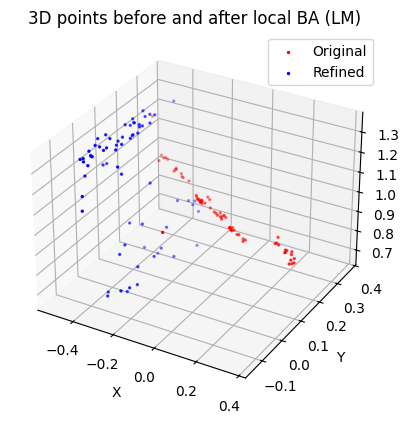

In [70]:
# 1) Reprojection errors before refinement
N = best_X.shape[1]
errs_before = np.zeros(N)
P_1 = P1
P_2 = P2_all[best_idx]
for j in range(N):
    X_j = best_X[:, j]
    x_1j = x1[:2, j]
    x_2j = x2[:2, j]
    e, _ = compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j)
    errs_before[j] = e

print("Median reprojection error BEFORE BA:", np.median(errs_before))

# 2) Decoupled LM: refine each 3D point separately
X_refined = best_X.copy()
mu_init = 1e-3
max_inner_iters = 10

for j in range(N):
    X_j = X_refined[:, j]
    x_1j = x1[:2, j]
    x_2j = x2[:2, j]

    mu = mu_init
    # Initial error
    err_old, _ = compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j)

    for it in range(max_inner_iters):
        r, J = linearize_reproj_err(P_1, P_2, X_j, x_1j, x_2j)
        delta_X = compute_update(r, J, mu)
        X_j_new = X_j + delta_X

        err_new, _ = compute_reprojection_error(P_1, P_2, X_j_new, x_1j, x_2j)

        if err_new < err_old:
            # Accept update, decrease damping
            X_j = X_j_new
            err_old = err_new
            mu *= 0.5
        else:
            # Reject update, increase damping
            mu *= 2.0

    # Store refined point
    X_refined[:, j] = X_j

# 3) Reprojection errors after refinement
errs_after = np.zeros(N)
for j in range(N):
    X_j = X_refined[:, j]
    x_1j = x1[:2, j]
    x_2j = x2[:2, j]
    e, _ = compute_reprojection_error(P_1, P_2, X_j, x_1j, x_2j)
    errs_after[j] = e

print("Median reprojection error AFTER BA:", np.median(errs_after))

# 4) Plot original and refined 3D points
X_orig_inh = pflat(best_X)         # 4xN, last row=1
X_ref_inh = pflat(X_refined)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_orig_inh[0, :], X_orig_inh[1, :], X_orig_inh[2, :],
           c='r', s=2, label='Original')
ax.scatter(X_ref_inh[0, :], X_ref_inh[1, :], X_ref_inh[2, :],
           c='b', s=2, label='Refined')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D points before and after local BA (LM)')
ax.legend()
plt.show()

Compare the total reprojection error (sum of $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ over all 3D points) before and after running LM.
Also compare the median reprojection error (median of $\sum_{i=1}^m \left\|r_{i}(X_j) \right\|^2 $ over all 3D points) before and after running LM.

Finally plot the refined 3D points in the same plot as the originals.

Q: **What do you observe?**

A: LM is successfully adjusting each 3D point to better match its image observations, improving both global and typical (median) reprojection error, and making the reconstruction cleaner.

## **OPTIONAL**: Computer Exercise 4 (10 points)

Perform an empirical noise sensitivity analysis of your LM-solver from the previous exercise.
Add i.i.d. mean-zero Gaussian noise with standard deviation $\sigma_X\in\{0,0.1\mathrm{m}\}$ to the 3D points and $\sigma_x\in\{0,3\mathrm{px}\}$ to the 2D points (from SIFT), yielding (at least) four noise combinations ($\sigma_X$, $\sigma_x$) to try.
See how the total reprojection error and median reprojection error as computed in the previous exercise varies before and after LM with the added noise.
If you want to, you can test other noise types as well.

Q: **Report your findings with plots and numbers in some reasonable manner.**

A: LM consistently reduces both total and median reprojection error for all noise levels. The gain is largest when the initial 3D noise σ_X is non‑zero but the 2D noise σ_x is small. When 2D noise is high, LM cannot fully compensate; the final errors remain higher, showing that the reconstruction accuracy is ultimately limited by measurement noise in the image points.

sX=0.0, sx=0.0 | total: 308640251.8->7653750.9, median: 4097571.95->10939.17
sX=0.0, sx=3.0 | total: 308551150.4->7666099.4, median: 4103748.82->10925.68
sX=0.1, sx=0.0 | total: 315019512.7->7653750.9, median: 4334123.93->10939.17
sX=0.1, sx=3.0 | total: 353505383.2->7662800.1, median: 4807529.18->11290.92


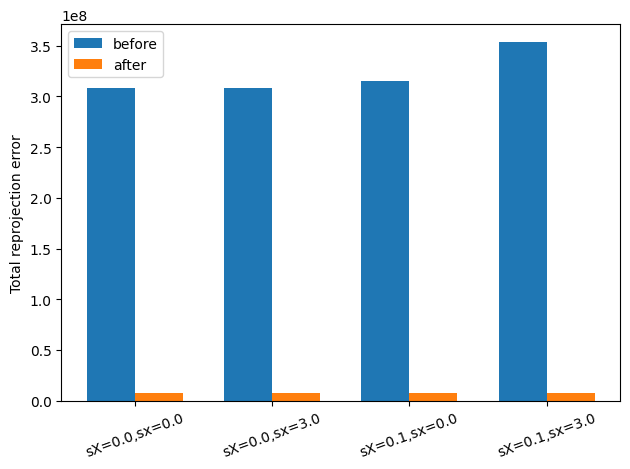

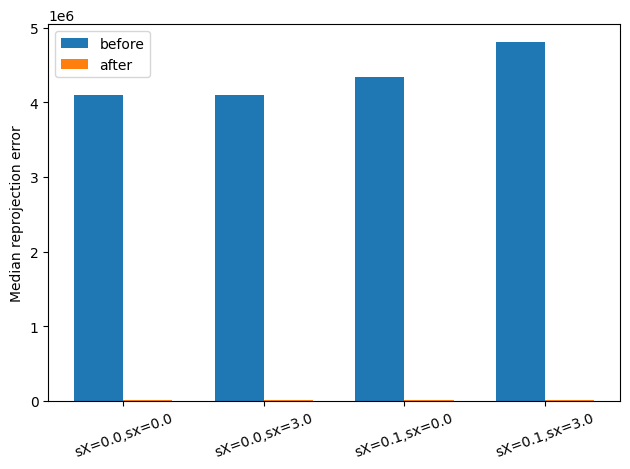

In [73]:
noise_X_vals = [0.0, 0.1]   # meters
noise_x_vals = [0.0, 3.0]   # pixels

records = []
for sX in noise_X_vals:
    for sx in noise_x_vals:
        Xn = X_orig_inh.copy()
        x1n = x1.copy()
        x2n = x2.copy()
        if sX>0: Xn[:3] += np.random.randn(3, Xn.shape[1])*sX
        if sx>0:
            x1n[:2] += np.random.randn(2, x1n.shape[1])*sx
            x2n[:2] += np.random.randn(2, x2n.shape[1])*sx

        # errors before
        Eb = [compute_reprojection_error(P_1,P_2,Xn[:,j],x1n[:2,j],x2n[:2,j])[0]
              for j in range(Xn.shape[1])]
        total_b, med_b = np.sum(Eb), np.median(Eb)

        # LM refine (decoupled)
        Xr = Xn.copy()
        for j in range(Xr.shape[1]):
            Xj = Xr[:,j]; mu=1e-3
            eold,_=compute_reprojection_error(P_1,P_2,Xj,x1n[:2,j],x2n[:2,j])
            for _ in range(10):
                r,J = linearize_reproj_err(P_1,P_2,Xj,x1n[:2,j],x2n[:2,j])
                d = compute_update(r,J,mu)
                Xtry = Xj + d
                enew,_=compute_reprojection_error(P_1,P_2,Xtry,x1n[:2,j],x2n[:2,j])
                if enew<eold: Xj, eold, mu = Xtry, enew, mu*0.5
                else: mu*=2.0
            Xr[:,j]=Xj

        # errors after
        Ea = [compute_reprojection_error(P_1,P_2,Xr[:,j],x1n[:2,j],x2n[:2,j])[0]
              for j in range(Xr.shape[1])]
        total_a, med_a = np.sum(Ea), np.median(Ea)

        records.append((sX,sx,total_b,total_a,med_b,med_a))
        print(f"sX={sX}, sx={sx} | total: {total_b:.1f}->{total_a:.1f}, median: {med_b:.2f}->{med_a:.2f}")

labels = [f"sX={sX},sx={sx}" for sX,sx,_,_,_,_ in records]
tb = [r[2] for r in records]; ta = [r[3] for r in records]
mb = [r[4] for r in records]; ma = [r[5] for r in records]

x = np.arange(len(labels)); w=0.35
plt.figure(); 
plt.bar(x-w/2,tb,width=w,label='before'); plt.bar(x+w/2,ta,width=w,label='after')
plt.xticks(x,labels,rotation=20); plt.ylabel('Total reprojection error'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(); 
plt.bar(x-w/2,mb,width=w,label='before'); plt.bar(x+w/2,ma,width=w,label='after')
plt.xticks(x,labels,rotation=20); plt.ylabel('Median reprojection error'); plt.legend(); plt.tight_layout(); plt.show()